# 04 · How well the model transfers

The point of this project is not accuracy on the scanner the model was trained on. It is accuracy on
scanners it has never seen, because that is what a clinic actually presents. This notebook measures
that, on the Kermany validation split for the training device, on OCTDL for a second device and on
the clinic scans for the third.

The headline is narrow and specific. Three of the four classes survive the change of device intact,
and one does not. The rest of the notebook establishes that and shows how the failure is
distributed.

## Setup

Both files below were written by scripts and are read as they are. `checkpoint_eval.csv` holds one
row per epoch with accuracy, macro-F1 and per-class recall on all three sets, and
`clinic_scan_e1.csv` holds one row per clinic scan with its prediction and class probabilities.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from ocular import config

EXP = config.ROOT / "experiments"
curve = pd.read_csv(EXP / "results" / "checkpoint_eval.csv").sort_values("epoch")
clinic = pd.read_csv(EXP / "results" / "clinic_scan_e1.csv")

e1 = curve[curve["epoch"] == 1].iloc[0]      # the delivered checkpoint
DEVICES = [("val", "Kermany val\n(Spectralis, trained on)"),
           ("octdl", "OCTDL\n(Optovue, unseen)"),
           ("clinic", "clinic\n(OPTOPOL, unseen)")]

## Only one class fails to transfer

The table below is the delivered checkpoint scored on all three devices, one row per class. Reading
it across shows what the change of scanner costs.

Three of the four classes hold or improve. CNV rises from 0.878 on the training device to 1.000 on
the clinic, DME from 0.964 to 1.000, and NORMAL from 0.954 to 1.000. Drusen does the opposite,
falling from 0.996 to 0.828 to 0.545, and it is the only class that falls at all.

The 0.996 is worth pausing on, because it contradicts the obvious reading of the clinic result.
Drusen is not a class this model finds hard. On the scanner it trained on it is the **best** of the
four, better than CNV, DME and NORMAL. Whatever goes wrong on the clinic device is not that drusen
are too small or too subtle to detect at this resolution, because at this same resolution the model
detects almost all of them.

In [2]:
table = pd.DataFrame(
    {label.split("\n")[0]: [e1[f"{key}_recall_{c}"] for c in config.CLASSES]
     for key, label in DEVICES},
    index=config.CLASSES,
).round(3)
table

,Kermany val,OCTDL,clinic
CNV,0.878,0.973,1.000
DME,0.964,0.923,1.000
DRUSEN,0.996,0.828,0.545
NORMAL,0.954,0.982,1.000


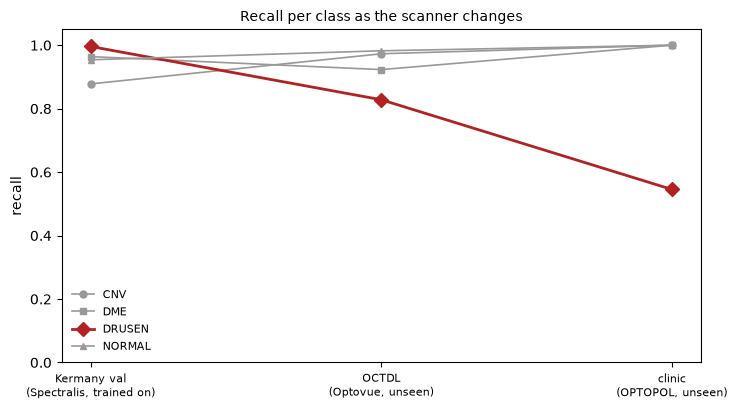

In [3]:
# per-class recall across the three devices, ordered by how far the device is from training
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(DEVICES))
for cls, style in zip(config.CLASSES, ["o-", "s-", "D-", "^-"]):
    y = [e1[f"{key}_recall_{cls}"] for key, _ in DEVICES]
    ax.plot(x, y, style, label=cls, linewidth=2 if cls == "DRUSEN" else 1.2,
            color="#b22222" if cls == "DRUSEN" else "0.6",
            markersize=7 if cls == "DRUSEN" else 5)
ax.set_xticks(x)
ax.set_xticklabels([label for _, label in DEVICES], fontsize=8)
ax.set_ylabel("recall")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, frameon=False, loc="lower left")
ax.set_title("Recall per class as the scanner changes", fontsize=10)
plt.tight_layout()
plt.show()

## Where the clinic errors land

The clinic set is thirty seven B-scans from a device used in neither training nor OCTDL. It is small,
so it confirms the model rather than selecting it.

The model is correct on twenty seven of them. The confusion matrix shows that the single CNV scan,
all five DME scans and all nine normal scans are classified correctly, and that every one of the ten
errors is a drusen scan. The failure is not spread thinly across the problem, it is confined to the
one class the previous section identified.

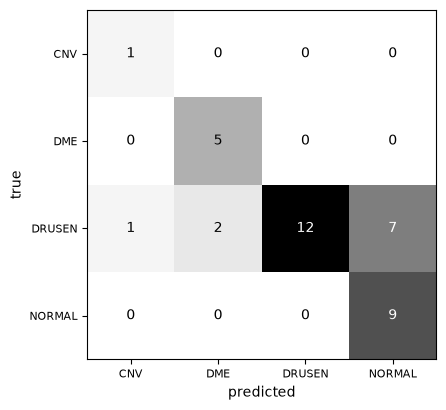

,class,correct,n,recall
0,CNV,1,1,1.000
1,DME,5,5,1.000
2,DRUSEN,12,22,0.545
3,NORMAL,9,9,1.000


In [4]:
labels = config.CLASSES
cm = confusion_matrix(clinic["truth"], clinic["pred"], labels=labels)

fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(cm, cmap="Greys")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = cm[i, j]
        ax.text(j, i, str(v), ha="center", va="center", fontsize=10,
                color="white" if v > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

recall = pd.DataFrame({
    "class": labels,
    "correct": cm.diagonal(),
    "n": cm.sum(axis=1),
    "recall": (cm.diagonal() / cm.sum(axis=1)).round(3),
})
recall

## The model is never uncertain about drusen

If the drusen signal were merely faint on this device, the scores would cluster near the decision
boundary and a different threshold would recover some of them. That is not what happens.

Sorting the twenty two clinic drusen scans by the probability the model assigns to drusen leaves a
gap in the middle. Ten sit at 0.265 or below and twelve at 0.828 or above, and nothing at all lands
between. The model is either confident the drusen are there or confident they are not, and it is
never in two minds. Whatever separates the two groups is not a matter of degree.

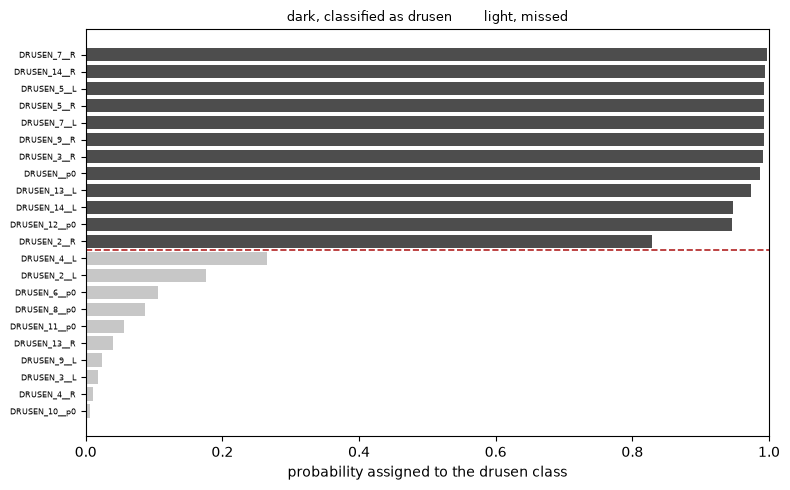

largest gap in the sorted scores: 0.265 -> 0.828
scans falling between 0.3 and 0.7: 0


In [5]:
dru = clinic[clinic["truth"] == "DRUSEN"].sort_values("p_DRUSEN").reset_index(drop=True)
hit = (dru["pred"] == "DRUSEN").to_numpy()
gap = np.diff(dru["p_DRUSEN"].to_numpy()).argmax()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.arange(len(dru)), dru["p_DRUSEN"],
        color=["0.30" if h else "0.78" for h in hit])
ax.axhline(gap + 0.5, color="#b22222", linestyle="--", linewidth=1.2)
ax.set_yticks(np.arange(len(dru)))
ax.set_yticklabels(dru["name"].str.replace(".png", "", regex=False), fontsize=6)
ax.set_xlabel("probability assigned to the drusen class")
ax.set_xlim(0, 1)
ax.set_title("dark, classified as drusen        light, missed", fontsize=9)
plt.tight_layout()
plt.show()

print(f"largest gap in the sorted scores: {dru['p_DRUSEN'][gap]:.3f} -> {dru['p_DRUSEN'][gap + 1]:.3f}")
print(f"scans falling between 0.3 and 0.7: {((dru['p_DRUSEN'] > 0.3) & (dru['p_DRUSEN'] < 0.7)).sum()}")

## What this leaves

The clinic result reads at first like a limit of the image, that a single printed B-scan cannot carry
enough of a druse to be recognised. The in-domain recall refuses that reading. At the same frame,
under the same preprocessing and from single slices, the model recovers 0.996 of drusen on the
scanner it trained on. The pathology is legible at this resolution, so what changed is not the amount
of information but the way the information looks.

What remains is the appearance of drusen itself. Each scanner renders the retinal layers with its own
contrast, speckle and edge rendering, and the model has learned drusen as they look on a Spectralis.
Where the OPTOPOL rendering happens to resemble that, the model is certain, and where it does not, it
is equally certain that nothing is there. That would produce exactly the split observed, and it fits
the recall falling as the device moves further from the training one.

This is a hypothesis and not a result. Testing it needs labelled drusen from more than one scanner,
which this project does not have, and that is the honest place to stop.

## Summary

- The delivered model is scored on **three devices**, one it trained on and two it has never seen.
- **Only drusen fails to transfer.** CNV, DME and NORMAL hold or improve across all three, while
  drusen falls from 0.996 to 0.828 to 0.545 as the device moves further from training.
- The in-domain recall of **0.996 makes drusen the best of the four classes**, which rules out the
  reading that the class is simply too subtle to detect at this resolution.
- On the clinic set, **all ten errors are drusen** and the scores are **bimodal**, with nothing
  between 0.27 and 0.83, so no threshold recovers them.
- What remains is a **difference in how each scanner renders drusen**, which this dataset cannot
  test and which is stated as a hypothesis rather than a finding.

The following notebook, `05`, looks at where the model directs its attention on these same scans.